In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from PIL import Image



px_to_um_flir = 3.45  # pixel-to-micron conversion factor
px_to_um_thorlabs = 5.2 

def focal_length(D, MFD, lambda_=767e-9):
    """"""
    return np.pi * D * MFD / (4*lambda_)

def gaussian_1d(x, amplitude, mean, stddev, offset):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2)) + offset

def gaussian_2d(xy, amplitude, x0, y0, sigma_x, sigma_y, theta, offset):
    x, y = xy
    a = (np.cos(theta)**2) / (2 * sigma_x**2) + (np.sin(theta)**2) / (2 * sigma_y**2)
    b = -(np.sin(2 * theta)) / (4 * sigma_x**2) + (np.sin(2 * theta)) / (4 * sigma_y**2)
    c = (np.sin(theta)**2) / (2 * sigma_x**2) + (np.cos(theta)**2) / (2 * sigma_y**2)
    g = amplitude * np.exp(-(a * (x - x0)**2 + 2 * b * (x - x0) * (y - y0) + c * (y - y0)**2)) + offset
    return g.ravel()

def fit_image_data(image_path, title='', px_to_um = 3.45, figsize=(4,3)):
    # 1. Load Image
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    data = np.asarray(img, dtype=float)
    
    rows, cols = data.shape
    x = np.arange(cols)
    y = np.arange(rows)
    X, Y = np.meshgrid(x, y)

    # 2. Marginal Projections (1D)
    x_data = np.sum(data, axis=0)
    y_data = np.sum(data, axis=1)

    # Initial guesses for 1D [amp, mean, stddev, offset]
    p0_x = [np.max(x_data), np.argmax(x_data), 10, np.min(x_data)]
    p0_y = [np.max(y_data), np.argmax(y_data), 10, np.min(y_data)]

    popt_x, pcov_x = curve_fit(gaussian_1d, x, x_data, p0=p0_x)
    popt_y, pcov_y = curve_fit(gaussian_1d, y, y_data, p0=p0_y)

    perr_x = np.sqrt(np.diag(pcov_x))
    perr_y = np.sqrt(np.diag(pcov_y))

    # 3. Full 2D Fit
    # Initial guess: [amp, x0, y0, sigma_x, sigma_y, theta, offset]
    p0_2d = [np.max(data), popt_x[1], popt_y[1], popt_x[2], popt_y[2], 0, np.min(data)]
    
    # Flatten grid for curve_fit
    popt_2d, pcov_2d = curve_fit(gaussian_2d, (X, Y), data.ravel(), p0=p0_2d)
    perr_2d = np.sqrt(np.diag(pcov_2d))

    # 4. Printing Results
    print("--- 1D Marginal Fits ---")
    print(f"X-Margin Width (sigma): {px_to_um*abs(popt_x[2]):.0f}({1e1*px_to_um*abs(perr_x[2]):.0f})" + r"um")
    print(f"Y-Margin Width (sigma): {px_to_um*abs(popt_y[2]):.0f}({1e1*px_to_um*abs(perr_y[2]):.0f})" + r"um")
    
    print("\n--- 2D Gaussian Fit ---")
    print(f"Sigma_X: {px_to_um*abs(popt_2d[3]):.1f}({1e1*px_to_um*abs(perr_2d[3]):.0f})" + r"um")
    print(f"Sigma_Y: {px_to_um*abs(popt_2d[4]):.1f}({1e1*px_to_um*abs(perr_2d[4]):.0f})" + r"um")
    print(f"Rotation (Skew) Theta: {popt_2d[5]:.3f}({1e1*perr_2d[5]:.3f}) rad")
    print(f" or {np.degrees(popt_2d[5]):.1f}({10*np.degrees(perr_2d[5]):.1f})°")

    # 5. Plotting
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    im = ax.imshow(data, cmap='viridis', origin='upper')
    ax.set_title(title)
    ax.set(xlabel=r'x (px)', ylabel=r'y (px)')
    
    # Overlay 2D fit contour
    Z_fit = gaussian_2d((X, Y), *popt_2d).reshape(rows, cols)
    ax.contour(X, Y, Z_fit, colors='w', alpha=0.5)
    
    plt.colorbar(im)
    plt.show()

### Desired Asphere focal length for fibre launch

In [33]:
focal_length(D=2.35e-3, MFD=5.3e-6)

lambda_ = 767e-9
D = 6.5e-3 * 4 * lambda_ / (np.pi * 5.3e-6)
# np.pi * D * MFD / (4*lambda_)
print(D)

D * 1.7 / 2 / 2

0.001197685990618331


0.0005090165460127907

--- 1D Marginal Fits ---
X-Margin Width (sigma): 1011(38)um
Y-Margin Width (sigma): 999(37)um

--- 2D Gaussian Fit ---
Sigma_X: 944.6(3)um
Sigma_Y: 1040.0(3)um
Rotation (Skew) Theta: 2.491(0.018) rad
 or 142.7(1.0)°


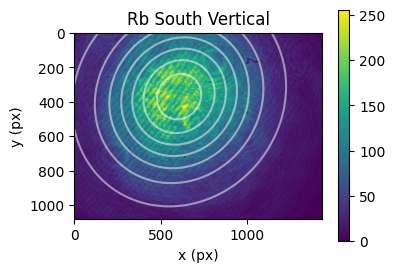

In [48]:
image_folder = '../data/mot_beam_images/Rb_pre_change/'

image_files = ["horizontal.png",
               "north_vert.png",
               "south_vert.png",]


image_titles = ['Rb Horizontal',
                'Rb North Vertical',
                'Rb South Vertical',]

camera_px_to_um = [px_to_um_flir, 
                   px_to_um_thorlabs, 
                   px_to_um_flir,]

i = 2  # Change this index to fit different images

image_file = image_folder + image_files[i]
fit_image_data(image_file, title=image_titles[i], 
               figsize=(4,3), px_to_um=camera_px_to_um[i])

--- 1D Marginal Fits ---
X-Margin Width (sigma): 1047(33)um
Y-Margin Width (sigma): 989(44)um

--- 2D Gaussian Fit ---
Sigma_X: 1052.5(3)um
Sigma_Y: 966.8(3)um
Rotation (Skew) Theta: -0.461(0.018) rad
 or -26.4(1.0)°


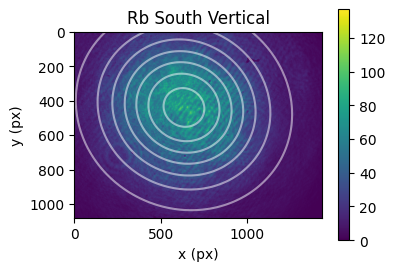

In [49]:
image_folder = '../data/mot_beam_images/Rb_post_change/'

image_files = ["Rb_NV.tif",
               "Rb_SV.bmp",]


image_titles = ['Rb North Vertical',
                'Rb South Vertical',]

camera_px_to_um = [px_to_um_thorlabs, 
                   px_to_um_flir,]

i = 1  # Change this index to fit different images

image_file = image_folder + image_files[i]
fit_image_data(image_file, title=image_titles[i], 
               figsize=(4,3), px_to_um=camera_px_to_um[i])

### MOT alley beams out of fibres

--- 1D Marginal Fits ---
X-Margin Width (sigma): 700(13)um
Y-Margin Width (sigma): 645(19)um

--- 2D Gaussian Fit ---
Sigma_X: 685.0(1)um
Sigma_Y: 656.9(1)um
Rotation (Skew) Theta: -0.459(0.029) rad
 or -26.3(1.7)°


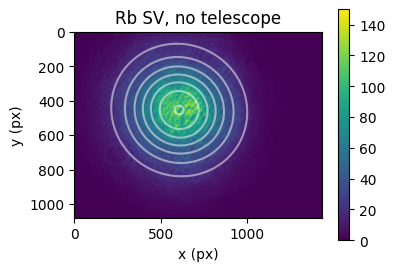

In [40]:
image_folder = '../data/mot_beam_images/2026-04-06/'

image_files = ["Rb_fibre_output_far_horizontalcam.png",
               "Rb_fibre_output_close_northvert_cam.tif",
               'KTrap_close_northvert_cam.tif',
               "KRP_close_northvert_cam.tif",
               'K_RP_4m.png',
               'KRP_southvertcam_newmotoptics.png',
               'K RP 1.tif',
               'K RP 2.bmp',
               'Rb no telescope NV.tif',
               'RB no telescope SV.bmp']


image_titles = ['Rb Far', 
                'Rb Close',
                'K Trap Close', 
                'K RP Close',
                'K RP Far',
                'K RP Close',
                'K RP Far, f=6.24mm',
                'K RP Close, f=6.24mm',
                'Rb NV, no telescope',
                'Rb SV, no telescope']

camera_px_to_um = [px_to_um_flir, 
                   px_to_um_thorlabs, 
                   px_to_um_thorlabs, 
                   px_to_um_thorlabs,
                   px_to_um_thorlabs,
                   px_to_um_flir,
                   px_to_um_thorlabs,
                   px_to_um_flir,
                   px_to_um_thorlabs,
                   px_to_um_flir,]

i = 9  # Change this index to fit different images

image_file = image_folder + image_files[i]
fit_image_data(image_file, title=image_titles[i], 
               figsize=(4,3), px_to_um=camera_px_to_um[i])

### Second attempt at MOT beam images

--- 1D Marginal Fits ---
X-Margin Width (sigma): 892(12)um
Y-Margin Width (sigma): 947(34)um

--- 2D Gaussian Fit ---
Sigma_X: 912.1(3)um
Sigma_Y: 1026.4(3)um
Rotation (Skew) Theta: 0.047(0.013) rad
 or 2.7(0.7)°


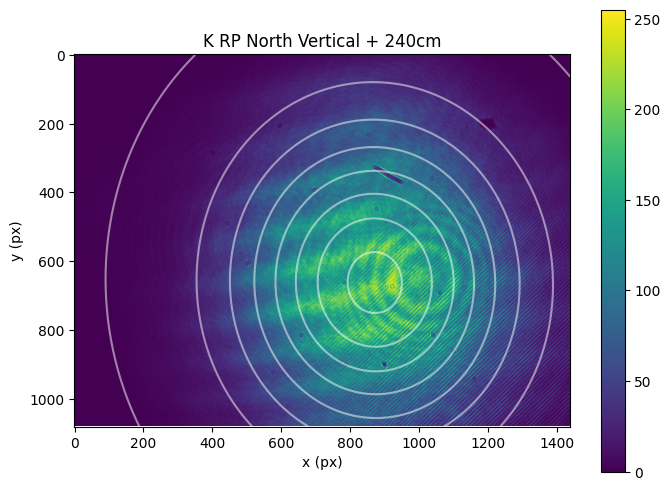

In [47]:
image_folder = '../data/mot_beam_images/'

image_files = ['Rb_southV.png',
               'Rb_northV_longarm.png',
               'K_Trap_vertS.png',
               'K_Trap_vertN_longarm.png',
               'K_RP_southV.png',
               'K_RP_northV_longarm.png',
               ]

image_titles = ['Rb South Vertical',
                'Rb North Vertical + 240cm',
                'K Trap South Vertical',
                'K Trap North Vertical + 240cm',
                'K RP South Vertical',
                'K RP North Vertical + 240cm',
                ]

i = 5  # Change this index to fit different images

image_file = image_folder + image_files[i]
fit_image_data(image_file, title=image_titles[i], figsize=(8,6))

In [13]:
def beam_expansion(z, w0, z0=0, lambda_=767e-9):
    z_R = np.pi * w0**2 / lambda_
    return w0 * np.sqrt(1 + ((z - z0) / z_R)**2)

z1 = 2.4

# --- Rb
w_0x = 970.2e-6
w_0y = 1091.1e-6

wx = 1317.0e-6
wy = 1136.5e-6

wx1 = beam_expansion(z1, w_0x)
wy1 = beam_expansion(z1, w_0y)

print("\n--- Rb beam expansion ---")
print(f"For an initial K beam size of ({w_0x*1e3:.3f}, {w_0y*1e3:.3f}) mm,")
print(f"we measure at {z1} m a beam size of ({wx*1e3:.3f}, {wy*1e3:.3f}) mm.")
print(f"Which is a {wx/w_0x:.3f}x expansion in x, {wy/w_0y:.3f}x expansion in y.")
print(f"The expected size at {z1} m is ({wx1*1e3:.3f}, {wy1*1e3:.3f}) mm.")
print(f"Predicting a {wx1/w_0x:.3f}x expansion in x, {wy1/w_0y:.3f}x expansion in y.")

# --- K
w_0x = 1152.1e-6
w_0y = 1120.3e-6

wx = 1615e-6
wy = 1483e-6

wx1 = beam_expansion(z1, w_0x)
wy1 = beam_expansion(z1, w_0y)

print("\n--- K beam expansion ---")
print(f"For an initial K beam size of ({w_0x*1e3:.3f}, {w_0y*1e3:.3f}) mm,")
print(f"we measure at {z1} m a beam size of ({wx*1e3:.3f}, {wy*1e3:.3f}) mm.")
print(f"Which is a {wx/w_0x:.3f}x expansion in x, {wy/w_0y:.3f}x expansion in y.")
print(f"The expected size at {z1} m is ({wx1*1e3:.3f}, {wy1*1e3:.3f}) mm.")
print(f"Predicting a {wx1/w_0x:.3f}x expansion in x, {wy1/w_0y:.3f}x expansion in y.")

# --- K RP
w_0x = 800.4e-6
w_0y = 726.0e-6

wx = 912.1e-6
wy = 1026.4e-6

wx1 = beam_expansion(z1, w_0x)
wy1 = beam_expansion(z1, w_0y)

print("\n--- K RP beam expansion ---")
print(f"For an initial K beam size of ({w_0x*1e3:.3f}, {w_0y*1e3:.3f}) mm,")
print(f"we measure at {z1} m a beam size of ({wx*1e3:.3f}, {wy*1e3:.3f}) mm.")
print(f"Which is a {wx/w_0x:.3f}x expansion in x, {wy/w_0y:.3f}x expansion in y.")
print(f"The expected size at {z1} m is ({wx1*1e3:.3f}, {wy1*1e3:.3f}) mm.")
print(f"Predicting a {wx1/w_0x:.3f}x expansion in x, {wy1/w_0y:.3f}x expansion in y.")



--- Rb beam expansion ---
For an initial K beam size of (0.970, 1.091) mm,
we measure at 2.4 m a beam size of (1.317, 1.136) mm.
Which is a 1.357x expansion in x, 1.042x expansion in y.
The expected size at 2.4 m is (1.143, 1.216) mm.
Predicting a 1.178x expansion in x, 1.115x expansion in y.

--- K beam expansion ---
For an initial K beam size of (1.152, 1.120) mm,
we measure at 2.4 m a beam size of (1.615, 1.483) mm.
Which is a 1.402x expansion in x, 1.324x expansion in y.
The expected size at 2.4 m is (1.259, 1.236) mm.
Predicting a 1.093x expansion in x, 1.104x expansion in y.

--- K RP beam expansion ---
For an initial K beam size of (0.800, 0.726) mm,
we measure at 2.4 m a beam size of (0.912, 1.026) mm.
Which is a 1.140x expansion in x, 1.414x expansion in y.
The expected size at 2.4 m is (1.085, 1.086) mm.
Predicting a 1.355x expansion in x, 1.495x expansion in y.


In [54]:
1615/912

1.7708333333333333

In [15]:
beam_expansion(4.0, w0=0.25e-3, lambda_=767e-9)

0.003914290648095057

### First attempt at MOT beam images

--- 1D Marginal Fits ---
X-Margin Width (sigma): 1047(27)um
Y-Margin Width (sigma): 1010(46)um

--- 2D Gaussian Fit ---
Sigma_X: 991.0(5)um
Sigma_Y: 1118.4(7)um
Rotation (Skew) Theta: -0.088(0.022) rad
 or -5.0(1.3)°


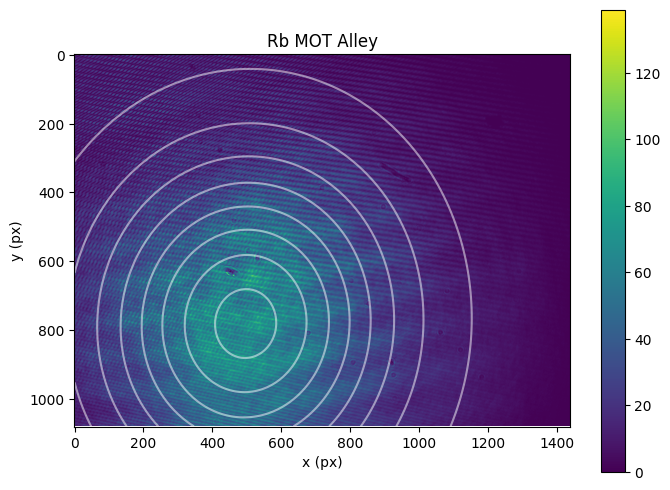

In [33]:
image_folder = '../data/mot_beam_images/'

image_files = ['K_dichroic_dump.png',
               'K_MOT_alley.png',
               'Rb_dichroic_dump.png',
               'Rb_MOT_alley.png',]

image_titles = ['K Dichroic Dump', 
                'K MOT Alley', 
                'Rb Dichroic Dump', 
                'Rb MOT Alley',]

i = 3  # Change this index to fit different images

image_file = image_folder + image_files[i]
fit_image_data(image_file, title=image_titles[i], figsize=(8,6))

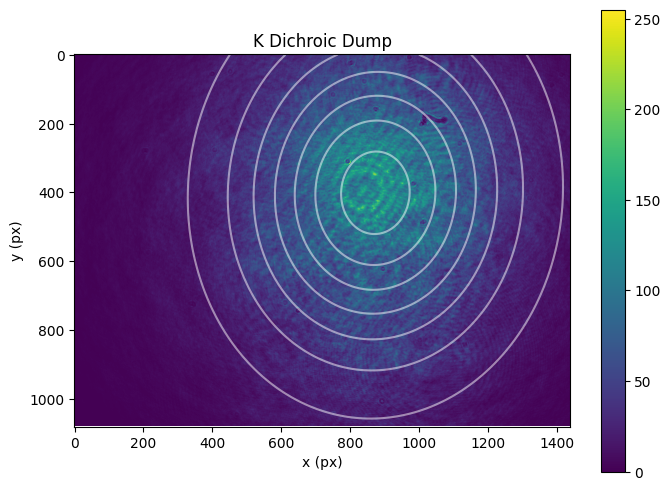

--- 1D Marginal Fits ---
X-Margin Width (sigma): 878(22)um
Y-Margin Width (sigma): 907(61)um

--- 2D Gaussian Fit ---
Sigma_X: 866.4(3)um
Sigma_Y: 1044.4(4)um
Rotation (Skew) Theta: -0.067(0.011) rad
 or -3.8(0.6)°

In [40]:
def beam_expansion(z, w0, lambda_=767e-9):
    z_R = np.pi * w0**2 / lambda_
    return w0 * np.sqrt(1 + (z / z_R)**2)

# --- K 
w_0x = 866.4e-6
w_0y = 1044.4e-6
z1 = 1.5
z2 = 1.7
wx1 = beam_expansion(z1, w_0x)
wy1 = beam_expansion(z1, w_0y)
wx2 = beam_expansion(z2, w_0x)
wy2 = beam_expansion(z2, w_0y)

print("\n--- K beam expansion ---")
print(f"For an initial K beam size of ({w_0x*1e3:.3f}, {w_0y*1e3:.3f}) mm,")
print(f"the expected size at {z1} m is ({wx1*1e3:.3f}, {wy1*1e3:.3f}) mm,")
print(f"the expected size at {z2} m is ({wx2*1e3:.3f}, {wy2*1e3:.3f}) mm.")


--- K beam expansion ---
For an initial K beam size of (0.866, 1.044) mm,
the expected size at 1.5 m is (0.964, 1.102) mm,
the expected size at 1.7 m is (0.990, 1.117) mm.
